In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

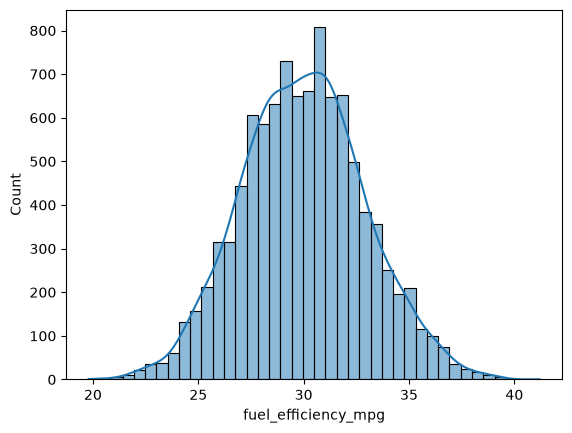

In [84]:
columns_to_use = ["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]
column_to_predict = "fuel_efficiency_mpg"
sns.histplot(data=df.fuel_efficiency_mpg, bins=40, kde=True)


# Question 1 
## Column with missing values

In [85]:
df.isna().sum()[columns_to_use]

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Question 2
## Median for variable 'horsepower'

In [86]:
df.horsepower.median()

np.float64(254.0)

## Prepare and split the dataset

In [87]:
def prepare_and_split_dataset(df, seed = 42) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test


In [88]:
def train_linear_regression(X, y) -> tuple[float, np.ndarray]:

    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def root_mean_squared_error(y_true, y_pred):
    error = y_true - y_pred
    se = error ** 2
    mse = se.mean()
    return mse ** 0.5

In [89]:
def prepare_data(df_train, df_val, df_test, column_to_predict):
    y_train = df_train[column_to_predict].values
    y_val = df_val[column_to_predict].values
    y_test = df_test[column_to_predict].values

    X_train_df = df_train.drop(columns=[column_to_predict])
    X_val_df = df_val.drop(columns=[column_to_predict])
    X_test_df = df_test.drop(columns=[column_to_predict])

    return X_train_df, X_val_df, X_test_df, y_train, y_val, y_test

In [90]:
df_train, df_val, df_test = prepare_and_split_dataset(df[columns_to_use])

X_train_df, X_val_df, X_test_df, y_train, y_val, y_test = prepare_data(df_train, df_val, df_test, column_to_predict)

### Option 1: fill with O

In [91]:
X_train_zero = X_train_df.fillna(0).values
X_val_zero = X_val_df.fillna(0).values


w0, w = train_linear_regression(X_train_zero, y_train)
y_pred_val = w0 + X_val_zero.dot(w)

score_zero = root_mean_squared_error(y_val, y_pred_val)
round(score_zero, 3)

np.float64(2.205)

In [92]:
mean_hosepower = X_train_df['horsepower'].mean()

X_train_mean = X_train_df.fillna(mean_hosepower).values
X_val_mean = X_val_df.fillna(mean_hosepower).values

w0, w = train_linear_regression(X_train_mean, y_train)
y_pred_val = w0 + X_val_mean.dot(w)
score_mean = root_mean_squared_error(y_val, y_pred_val)
round(score_mean, 3)

np.float64(2.202)

# Question 4

In [93]:
def train_linear_regression(X, y, r = 0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [94]:
rs = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in rs:
    w0, w = train_linear_regression(X_train_zero, y_train, r)
    y_pred_val = w0 + X_val_zero.dot(w)
    score = root_mean_squared_error(y_val, y_pred_val)
    print(f"r = {r}: score = {round(score, 4)}")
    

r = 0: score = 2.2053
r = 0.01: score = 2.2058
r = 0.1: score = 2.2241
r = 1: score = 2.3492
r = 5: score = 2.4094
r = 10: score = 2.4195
r = 100: score = 2.4292


# Question 5

In [95]:
scores = []
for seed in range(10):
    df_train, df_val, df_test = prepare_and_split_dataset(df[columns_to_use], seed=seed)
    X_train_df, X_val_df, X_test_df, y_train, y_val, y_test = prepare_data(df_train, df_val, df_test, column_to_predict)

    X_train_zero = X_train_df.fillna(0).values
    X_val_zero = X_val_df.fillna(0).values

    w0, w = train_linear_regression(X_train_zero, y_train)
    y_val_pred = w0 + X_val_zero.dot(w)

    score = root_mean_squared_error(y_val, y_val_pred)
    print(f"Seed: {seed}, RMSE: {score}")
    scores.append(score)

print(f"Standard deviation of score: {round(np.std(scores), 3)}")
    

Seed: 0, RMSE: 2.240475918423889
Seed: 1, RMSE: 2.203078174730148
Seed: 2, RMSE: 2.163338005872001
Seed: 3, RMSE: 2.205095895231721
Seed: 4, RMSE: 2.2000691297284742
Seed: 5, RMSE: 2.246758310581761
Seed: 6, RMSE: 2.269900814547123
Seed: 7, RMSE: 2.1911549015426077
Seed: 8, RMSE: 2.21708177493273
Seed: 9, RMSE: 2.2066564366686747
Standard deviation of score: 0.029


# Question 6

In [99]:
df_train, df_val, df_test = prepare_and_split_dataset(df[columns_to_use], seed=9)

df_combined = pd.concat([df_train, df_val])

y_combined = df_combined[column_to_predict].values
y_test = df_test[column_to_predict].values


X_combined_df = df_combined.drop(columns=[column_to_predict])
X_combined = X_combined_df.fillna(0).values

X_test_df = df_test.drop(columns=[column_to_predict])
X_test = X_test_df.fillna(0).values

w0, w = train_linear_regression(X_combined, y_combined, r = 0.001)
y_pred_test = w0 + X_test.dot(w)

score = root_mean_squared_error(y_test, y_pred_test)
print("Test RMSE:", round(score, 3))

Test RMSE: 2.236
